In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("heart.csv")
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
X = data.drop("target", axis=1)

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

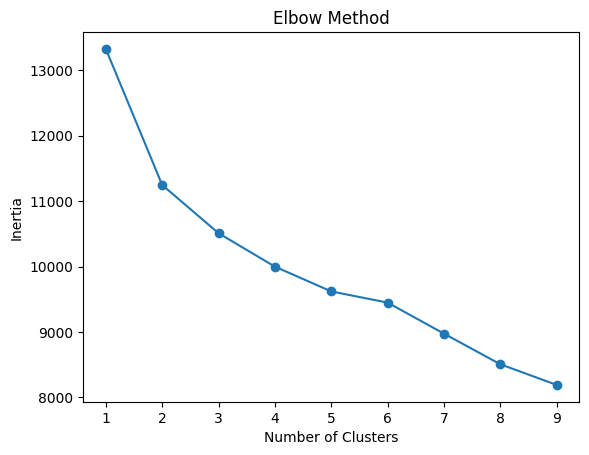

In [5]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [25]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

data['cluster'] = clusters

In [26]:
data['cluster'].value_counts()

,count
cluster,
1,642
0,383


In [27]:
data.groupby('cluster').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
cluster,,,,,,,,,,,,,,
0,58.310705,0.762402,0.224543,135.882507,252.926893,0.169713,0.483029,130.657963,0.723238,1.890339,1.005222,1.295039,2.577023,0.107050
1,52.121495,0.655763,1.370717,129.063863,241.867601,0.137072,0.557632,160.124611,0.105919,0.583022,1.612150,0.431464,2.172897,0.755452


/tmp/ipykernel_4465/1906765621.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_clusters))


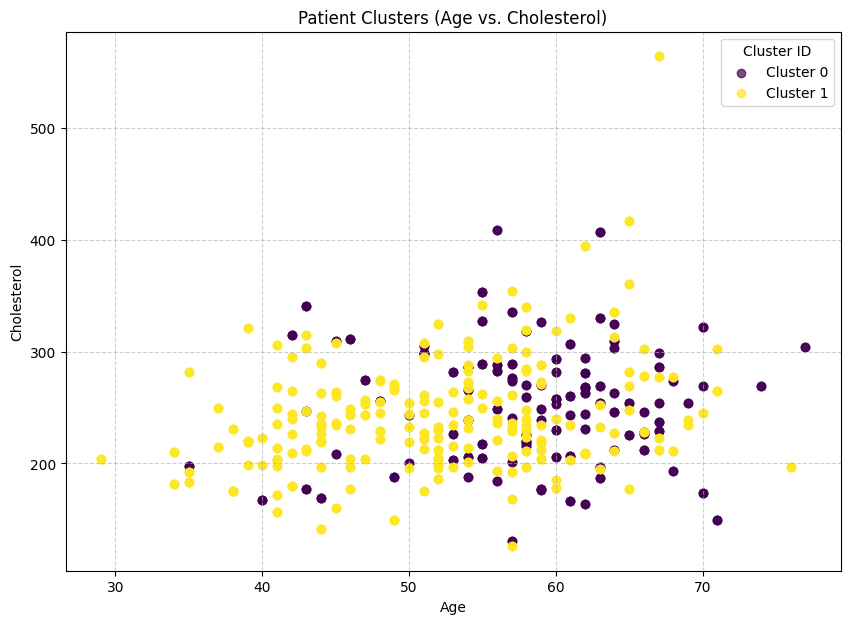

In [28]:
plt.figure(figsize=(10, 7))

# Get unique clusters
unique_clusters = data['cluster'].unique()

# Use a colormap to assign distinct colors
colors = plt.cm.get_cmap('viridis', len(unique_clusters))

for i, cluster_id in enumerate(sorted(unique_clusters)): # Sort unique_clusters for consistent legend order
    cluster_data = data[data['cluster'] == cluster_id]
    plt.scatter(cluster_data['age'], cluster_data['chol'],
                color=colors(i),
                label=f'Cluster {cluster_id}',
                alpha=0.7)

plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.title("Patient Clusters (Age vs. Cholesterol)")
plt.legend(title="Cluster ID")
plt.grid(True, linestyle='--', alpha=0.6) # Add a grid for better readability
plt.show()

Key Insights:

- Three distinct patient groups were identified.
- Cluster 0 shows higher cholesterol and age, suggesting higher cardiovascular risk.
- Cluster 1 appears to represent younger, lower-risk individuals.
- This type of segmentation could support personalised care strategies.